<a href="https://colab.research.google.com/github/munozfloresnelsont12-oss/PPIA-github/blob/main/Regresion_lineal_viviendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar librerias y dataframe
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
california = fetch_california_housing(as_frame=True)

In [ ]:
# Separar los datos y etiquetas en X, y
X = california.data
y = california.target

In [ ]:
df = X.copy()
df['MedHouseVal'] = y

In [ ]:
print("Dataset cargado con éxito.")
print(f"Forma del DataFrame: {df.shape}")

Dataset cargado con éxito.
Forma del DataFrame: (20640, 9)


In [ ]:
print("Primeras filas del DataFrame:")
print(df.head())


Primeras filas del DataFrame:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
print("--- Información General (.info()) ---")
df.info()

--- Información General (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Descripción estadística (.describe())
print("--- Descripción Estadística (.describe()) ---")
print(df.describe())
print("\n" + "="*50 + "\n")

--- Descripción Estadística (.describe()) ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532   

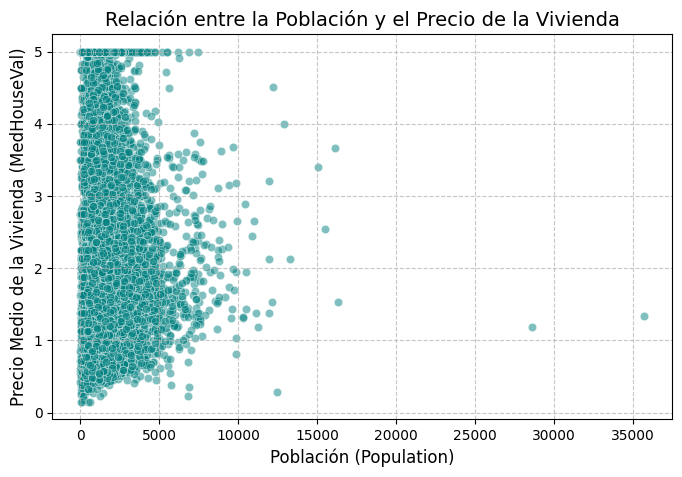

In [ ]:
# Representacion grafica usando sns.scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Population', y='MedHouseVal', alpha=0.5, color='teal')
plt.title('Relación entre la Población y el Precio de la Vivienda', fontsize=14)
plt.xlabel('Población (Population)', fontsize=12)
plt.ylabel('Precio Medio de la Vivienda (MedHouseVal)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. División de datos en entrenamiento (80%) y prueba (20%)
# Usamos las variables X (características) e y (etiquetas) que definimos en el paso 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Inicializar el escalador estándar
scaler = StandardScaler()

# 3. Ajustar y transformar el conjunto de entrenamiento, y transformar el de prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificación de las dimensiones
print("Datos divididos y escalados con éxito.")
print(f"Tamaño de X_train (escalado): {X_train_scaled.shape}")
print(f"Tamaño de X_test (escalado): {X_test_scaled.shape}")

Datos divididos y escalados con éxito.
Tamaño de X_train (escalado): (16512, 8)
Tamaño de X_test (escalado): (4128, 8)


In [ ]:

# Entrenamiento del Modelo

from sklearn.linear_model import LinearRegression

# 1. Inicializar el modelo de Regresión Lineal
model = LinearRegression()

# 2. Entrenar al modelo utilizando el conjunto de entrenamiento escalado
model.fit(X_train_scaled, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


In [ ]:

# Evaluación del Modelo

from sklearn.metrics import mean_squared_error

# 1. Realizar predicciones con tres ejemplos del conjunto de prueba
# Tomamos los primeros 3 registros de X_test_scaled
X_sample = X_test_scaled[:3]
y_sample_true = y_test[:3].values  # Valores reales

predictions_sample = model.predict(X_sample)

print("--- Predicciones de muestra (3 ejemplos) ---")
for i in range(3):
    print(f"Ejemplo {i+1}: Valor Real = {y_sample_true[i]:.4f} | Predicción = {predictions_sample[i]:.4f}")
print("\n" + "="*50 + "\n")

# 2. Calcular e imprimir el Error Cuadrático Medio (MSE) en todo el conjunto de prueba
y_pred_all = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred_all)

print(f"El Error Cuadrático Medio (MSE) del modelo es: {mse:.4f}")

--- Predicciones de muestra (3 ejemplos) ---
Ejemplo 1: Valor Real = 0.4770 | Predicción = 0.7191
Ejemplo 2: Valor Real = 0.4580 | Predicción = 1.7640
Ejemplo 3: Valor Real = 5.0000 | Predicción = 2.7097


El Error Cuadrático Medio (MSE) del modelo es: 0.5559


En esta actividad se implementó con éxito un flujo de trabajo para predecir los precios de vivienda en California mediante Regresión Lineal.

Preparación de datos: La correcta división del dataset y la aplicación del escalado estándar garantizaron que la diferencia de magnitudes entre variables (como población y habitaciones) no afectara el rendimiento del algoritmo.

El modelo alcanzó un Error Cuadrático Medio (MSE) de 0.5559, demostrando una capacidad predictiva inicial sólida y rápida de entrenar.

Dado que el mercado inmobiliario suele comportarse de forma compleja y no lineal, este modelo lineal funciona como una excelente línea base